# Week 2 – Day 4: Model Evaluation and Error Analysis

This notebook performs the formal evaluation of the traditional machine-learning
baselines developed during Week 2.

The Linear Regression and XGBoost models are evaluated on the same holdout dataset
using RMSE and MAPE.

## Objectives

- Load the trained Linear Regression and XGBoost models.
- Load the common holdout dataset.
- Generate predictions from both models.
- Calculate RMSE and MAPE.
- Compare baseline model performance.
- Analyze prediction errors.
- Identify price ranges with higher prediction errors.
- Visualize actual versus predicted prices.
- Prepare the baseline results for comparison with spatial models.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error,
    r2_score
)

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT,"data","processed","week-2")

MODEL_DIR = os.path.join(PROJECT_ROOT,"models")

PREDICTION_DIR = os.path.join(DATA_DIR,"predictions")

REPORT_DIR = os.path.join(PROJECT_ROOT,"reports","week-2")

os.makedirs(PREDICTION_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Project root: e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation
Data directory: e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2
Model directory: e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\models


In [3]:
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17277, 15)
X_test : (4320, 15)
y_train: (17277,)
y_test : (4320,)


In [4]:
linear_model_path = os.path.join(MODEL_DIR,"linear_regression_baseline.pkl")

xgb_model_path = os.path.join(MODEL_DIR,"xgboost_baseline.pkl")

linear_model = joblib.load(linear_model_path)

xgb_model = joblib.load(xgb_model_path)

print("Linear Regression model loaded successfully.")
print("XGBoost model loaded successfully.")

Linear Regression model loaded successfully.
XGBoost model loaded successfully.


In [5]:
linear_predictions = linear_model.predict(X_test)

xgb_predictions = xgb_model.predict(X_test)

print("Linear Regression predictions:", len(linear_predictions))
print("XGBoost predictions:", len(xgb_predictions))

Linear Regression predictions: 4320
XGBoost predictions: 4320


In [6]:
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mape = (mean_absolute_percentage_error(y_true,y_pred) * 100)
    mae = mean_absolute_error(y_true,y_pred)
    r2 = r2_score(y_true,y_pred)

    return {
        "RMSE": rmse,
        "MAPE (%)": mape,
        "MAE": mae,
        "R2 Score": r2
    }

In [7]:
linear_metrics = evaluate_model(y_test,linear_predictions)

linear_metrics

{'RMSE': np.float64(129959.7354735008),
 'MAPE (%)': 23.503192728641366,
 'MAE': 99623.90095964841,
 'R2 Score': 0.7273521673628122}

In [8]:
xgb_metrics = evaluate_model(y_test,xgb_predictions)

xgb_metrics

{'RMSE': np.float64(103398.1686957477),
 'MAPE (%)': 17.313262170379055,
 'MAE': 75525.96851490161,
 'R2 Score': 0.827412194652471}

In [9]:
evaluation_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "RMSE": [
        linear_metrics["RMSE"],
        xgb_metrics["RMSE"]
    ],
    "MAPE (%)": [
        linear_metrics["MAPE (%)"],
        xgb_metrics["MAPE (%)"]
    ],
    "MAE": [
        linear_metrics["MAE"],
        xgb_metrics["MAE"]
    ],
    "R2 Score": [
        linear_metrics["R2 Score"],
        xgb_metrics["R2 Score"]
    ]
})

evaluation_results

,Model,RMSE,MAPE (%),MAE,R2 Score
0,Linear Regression,129959.735474,23.503193,99623.900960,0.727352
1,XGBoost,103398.168696,17.313262,75525.968515,0.827412


In [10]:
best_rmse_model = evaluation_results.loc[evaluation_results["RMSE"].idxmin(),"Model"]
best_mape_model = evaluation_results.loc[evaluation_results["MAPE (%)"].idxmin(),"Model"]
best_r2_model = evaluation_results.loc[evaluation_results["R2 Score"].idxmax(),"Model"]

print("Best model by RMSE :", best_rmse_model)
print("Best model by MAPE :", best_mape_model)
print("Best model by R²   :", best_r2_model)

Best model by RMSE : XGBoost
Best model by MAPE : XGBoost
Best model by R²   : XGBoost


In [11]:
linear_rmse = linear_metrics["RMSE"]
xgb_rmse = xgb_metrics["RMSE"]

linear_mape = linear_metrics["MAPE (%)"]
xgb_mape = xgb_metrics["MAPE (%)"]

rmse_improvement = ((linear_rmse - xgb_rmse) / linear_rmse) * 100
mape_improvement = ((linear_mape - xgb_mape) / linear_mape) * 100

print(
    f"RMSE improvement with XGBoost: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"MAPE improvement with XGBoost: "
    f"{mape_improvement:.2f}%"
)

RMSE improvement with XGBoost: 20.44%
MAPE improvement with XGBoost: 26.34%


In [12]:
error_analysis = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Regression Prediction": linear_predictions,
    "XGBoost Prediction": xgb_predictions
})

error_analysis["Linear Absolute Error"] = (error_analysis["Actual Price"] - error_analysis["Linear Regression Prediction"]).abs()

error_analysis["XGBoost Absolute Error"] = (error_analysis["Actual Price"] - error_analysis["XGBoost Prediction"]).abs()

error_analysis["Linear Percentage Error"] = (error_analysis["Linear Absolute Error"] / error_analysis["Actual Price"]) * 100

error_analysis["XGBoost Percentage Error"] = (error_analysis["XGBoost Absolute Error"] / error_analysis["Actual Price"]) * 100

error_analysis.head(10)

,Actual Price,Linear Regression Prediction,XGBoost Prediction,Linear Absolute Error,XGBoost Absolute Error,Linear Percentage Error,XGBoost Percentage Error
0,132500.0,264782.604623,220356.078125,132282.604623,87856.078125,99.835928,66.306474
1,415000.0,373801.540590,384586.093750,41198.459410,30413.906250,9.927340,7.328652
2,494000.0,158438.279757,387701.093750,335561.720243,106298.906250,67.927474,21.517997
3,355000.0,437002.928582,379625.250000,82002.928582,24625.250000,23.099417,6.936690
4,606000.0,447632.252502,494013.750000,158367.747498,111986.250000,26.133292,18.479579
5,640000.0,557081.655477,522252.875000,82918.344523,117747.125000,12.955991,18.397988
6,256500.0,194699.730525,230427.718750,61800.269475,26072.281250,24.093672,10.164632
7,959000.0,942969.821261,999468.062500,16030.178739,40468.062500,1.671551,4.219819
8,445000.0,490116.462260,538041.750000,45116.462260,93041.750000,10.138531,20.908258
9,254000.0,475994.617690,460646.375000,221994.617690,206646.375000,87.399456,81.356841


In [13]:
worst_xgb_predictions = (error_analysis.sort_values(by="XGBoost Absolute Error",ascending=False).head(20))

worst_xgb_predictions

,Actual Price,Linear Regression Prediction,XGBoost Prediction,Linear Absolute Error,XGBoost Absolute Error,Linear Percentage Error,XGBoost Percentage Error
1192,890000.0,3.144716e+05,3.110185e+05,575528.366161,578981.50000,64.666109,65.054101
2228,1010000.0,5.311649e+05,4.437007e+05,478835.146697,566299.28125,47.409420,56.069236
2562,1129575.0,5.621294e+05,5.922935e+05,567445.611892,537281.50000,50.235320,47.564925
816,1050000.0,3.389689e+05,5.151842e+05,711031.146658,534815.84375,67.717252,50.934842
1382,1014250.0,4.714494e+05,4.943996e+05,542800.572572,519850.37500,53.517434,51.254659
2509,540000.0,9.152779e+05,1.057989e+06,375277.857141,517989.37500,69.495899,95.923958
3844,900000.0,4.224672e+05,4.015866e+05,477532.811714,498413.37500,53.059201,55.379264
3910,1129575.0,5.332481e+05,6.378881e+05,596326.874708,491686.87500,52.792145,43.528484
143,257000.0,6.760651e+05,7.086984e+05,419065.107404,451698.37500,163.060353,175.758123
906,1110000.0,5.322369e+05,6.612259e+05,577763.100036,448774.06250,52.050730,40.430096


In [14]:
error_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "Mean Absolute Error": [
        error_analysis["Linear Absolute Error"].mean(),
        error_analysis["XGBoost Absolute Error"].mean()
    ],
    "Mean Percentage Error": [
        error_analysis["Linear Percentage Error"].mean(),
        error_analysis["XGBoost Percentage Error"].mean()
    ]
})

error_summary

,Model,Mean Absolute Error,Mean Percentage Error
0,Linear Regression,99623.900960,23.503193
1,XGBoost,75525.968515,17.313262


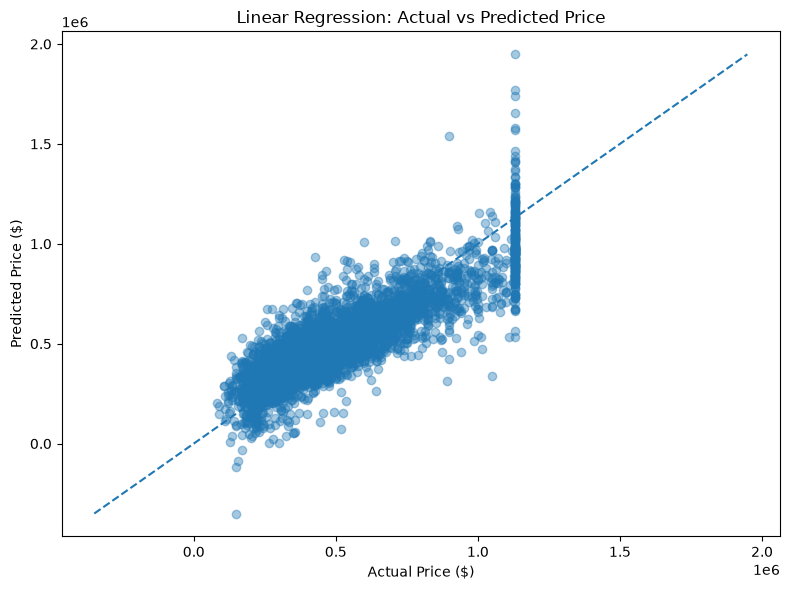

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test,linear_predictions,alpha=0.4)

min_price = min(y_test.min(),linear_predictions.min())
max_price = max(y_test.max(),linear_predictions.max())

plt.plot([min_price, max_price],[min_price, max_price],linestyle="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Linear Regression: Actual vs Predicted Price")

plt.tight_layout()
plt.show()

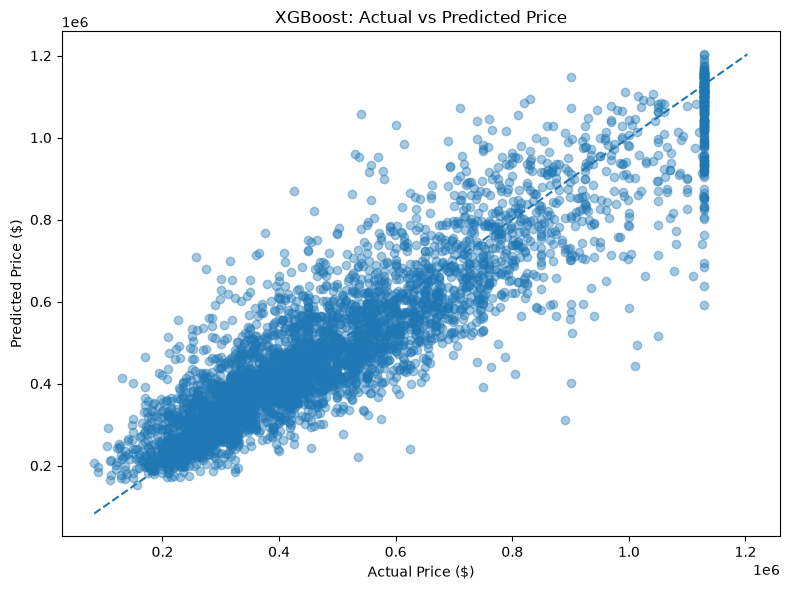

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test,xgb_predictions,alpha=0.4)

min_price = min(y_test.min(),xgb_predictions.min())
max_price = max(y_test.max(),xgb_predictions.max())

plt.plot([min_price, max_price],[min_price, max_price],linestyle="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("XGBoost: Actual vs Predicted Price")

plt.tight_layout()
plt.show()

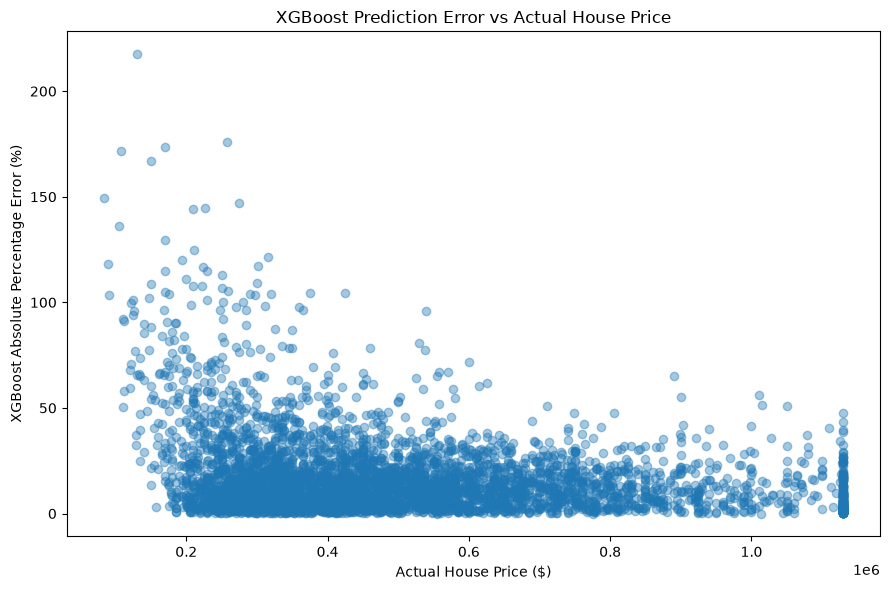

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(error_analysis["Actual Price"],error_analysis["XGBoost Percentage Error"],alpha=0.4)

plt.xlabel("Actual House Price ($)")
plt.ylabel("XGBoost Absolute Percentage Error (%)")
plt.title("XGBoost Prediction Error vs Actual House Price")

plt.tight_layout()
plt.show()

In [18]:
error_analysis["Price Range"] = pd.cut(
    error_analysis["Actual Price"],
    bins=[0,300000,500000,750000,1000000,np.inf],
    labels=["Below $300K","$300K–$500K","$500K–$750K","$750K–$1M","Above $1M"]
)

price_range_analysis = (
    error_analysis
    .groupby("Price Range", observed=False)
    .agg(
        Properties=("Actual Price", "count"),
        Average_Actual_Price=("Actual Price", "mean"),
        XGBoost_MAE=("XGBoost Absolute Error", "mean"),
        XGBoost_MAPE=("XGBoost Percentage Error", "mean")
    )
    .reset_index()
)

price_range_analysis

,Price Range,Properties,Average_Actual_Price,XGBoost_MAE,XGBoost_MAPE
0,Below $300K,934,2.418858e+05,60886.635088,27.311698
1,$300K–$500K,1586,3.969692e+05,63901.142654,16.308357
2,$500K–$750K,1106,6.099032e+05,86966.127769,14.293611
3,$750K–$1M,401,8.548720e+05,103961.404458,12.152759
4,Above $1M,293,1.112575e+06,103016.361988,9.341714


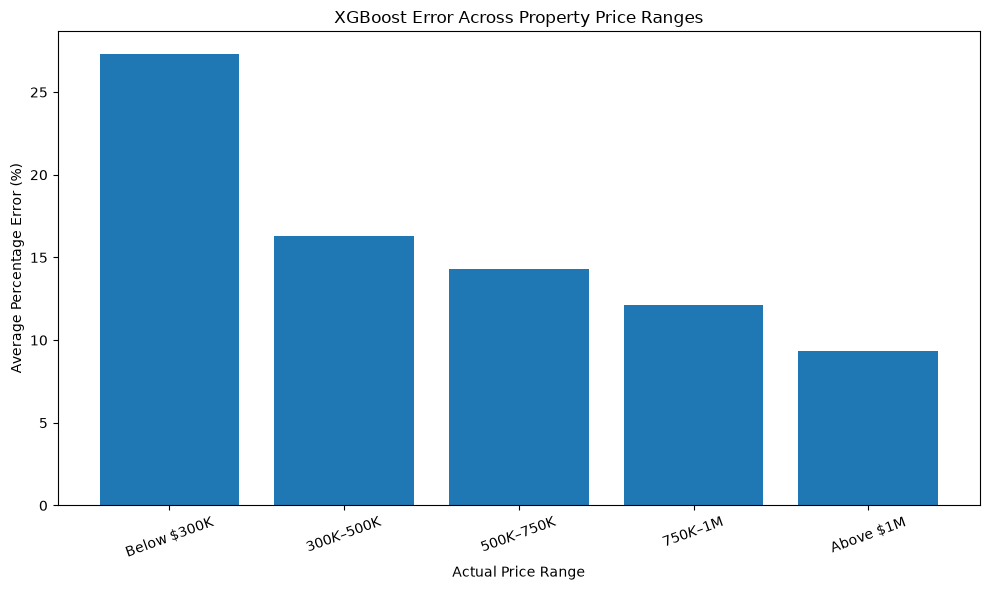

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(price_range_analysis["Price Range"].astype(str),price_range_analysis["XGBoost_MAPE"])

plt.xlabel("Actual Price Range")
plt.ylabel("Average Percentage Error (%)")
plt.title("XGBoost Error Across Property Price Ranges")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [20]:
evaluation_path = os.path.join(DATA_DIR,"model_evaluation.csv")

evaluation_results.to_csv(evaluation_path,index=False)

print("Evaluation results saved:")
print(evaluation_path)

Evaluation results saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\model_evaluation.csv


In [21]:
error_path = os.path.join(DATA_DIR,"prediction_error_analysis.csv")

error_analysis.to_csv(error_path,index=False)

print("Prediction error analysis saved:")
print(error_path)

Prediction error analysis saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\prediction_error_analysis.csv


In [22]:
price_range_path = os.path.join(DATA_DIR,"price_range_error_analysis.csv")

price_range_analysis.to_csv(price_range_path,index=False)

print("Price-range error analysis saved:")
print(price_range_path)

Price-range error analysis saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\price_range_error_analysis.csv


In [23]:
prediction_comparison = error_analysis[
    [
        "Actual Price",
        "Linear Regression Prediction",
        "XGBoost Prediction"
    ]
].copy()

prediction_comparison_path = os.path.join(PREDICTION_DIR,"model_prediction_comparison.csv")

prediction_comparison.to_csv(prediction_comparison_path,index=False)

print("Prediction comparison saved:")
print(prediction_comparison_path)

Prediction comparison saved:
e:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-2\predictions\model_prediction_comparison.csv


In [24]:
print("=" * 70)
print("WEEK 2 – DAY 4 VALIDATION")
print("=" * 70)

print(f"Training records : {len(X_train):,}")
print(f"Holdout records  : {len(X_test):,}")
print(f"Features         : {X_test.shape[1]}")

print("\nModel Performance")
print("-" * 70)

print(
    f"Linear Regression RMSE : "
    f"${linear_rmse:,.2f}"
)

print(
    f"XGBoost RMSE           : "
    f"${xgb_rmse:,.2f}"
)

print(
    f"Linear Regression MAPE : "
    f"{linear_mape:.2f}%"
)

print(
    f"XGBoost MAPE           : "
    f"{xgb_mape:.2f}%"
)

print("\nBest RMSE model:", best_rmse_model)
print("Best MAPE model:", best_mape_model)
print("Best R² model  :", best_r2_model)

print("\nDay 4 evaluation completed successfully.")

WEEK 2 – DAY 4 VALIDATION
Training records : 17,277
Holdout records  : 4,320
Features         : 15

Model Performance
----------------------------------------------------------------------
Linear Regression RMSE : $129,959.74
XGBoost RMSE           : $103,398.17
Linear Regression MAPE : 23.50%
XGBoost MAPE           : 17.31%

Best RMSE model: XGBoost
Best MAPE model: XGBoost
Best R² model  : XGBoost

Day 4 evaluation completed successfully.
